# SBI for ClonalOrigin sequential model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sbi.inference import NPE_C
from sbi.analysis import plot_summary

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Load simulation data

In [2]:
x_o = np.loadtxt('../data/x_o.csv', delimiter=",")
x_o = x_o[:8]
x_o

array([0.16571728, 0.16576999, 0.16727886, 0.03737374, 0.03794872,
       0.03769634, 0.04516129, 0.        ])

In [3]:
x_o_2000 = np.append(x_o, 2000.0)
x_o_2000 = torch.tensor(x_o_2000, device=torch_device)
x_o_2000 = x_o_2000.to(torch.float32)
x_o_2000 = x_o_2000.flatten()
x_o_2000_numpy = x_o_2000.cpu().numpy()
x_o_2000

tensor([1.6572e-01, 1.6577e-01, 1.6728e-01, 3.7374e-02, 3.7949e-02, 3.7696e-02,
        4.5161e-02, 0.0000e+00, 2.0000e+03])

In [4]:
x_o_500 = np.append(x_o, 500.0)
x_o_500 = torch.tensor(x_o_500, device=torch_device)
x_o_500 = x_o_500.to(torch.float32)
x_o_500 = x_o_500.flatten()
x_o_500_numpy = x_o_500.cpu().numpy()
x_o_500

tensor([1.6572e-01, 1.6577e-01, 1.6728e-01, 3.7374e-02, 3.7949e-02, 3.7696e-02,
        4.5161e-02, 0.0000e+00, 5.0000e+02])

In [5]:
x_o_6000 = np.append(x_o, 6000.0)
x_o_6000 = torch.tensor(x_o_6000, device=torch_device)
x_o_6000 = x_o_6000.to(torch.float32)
x_o_6000 = x_o_6000.flatten()
x_o_6000_numpy = x_o_6000.cpu().numpy()
x_o_6000

tensor([1.6572e-01, 1.6577e-01, 1.6728e-01, 3.7374e-02, 3.7949e-02, 3.7696e-02,
        4.5161e-02, 0.0000e+00, 6.0000e+03])

In [6]:
theta = np.loadtxt('../data/theta.csv', delimiter=",")
x = np.loadtxt('../data/x.csv', delimiter=",")

In [7]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()
theta

tensor([[1.4161e-01, 2.9838e+02, 4.2170e-02, 1.6160e+03],
        [2.2739e-02, 4.4266e+02, 9.0736e-02, 8.6350e+03],
        [1.0255e-01, 1.4099e+02, 5.0111e-02, 4.1060e+03],
        ...,
        [1.4787e-01, 4.3944e+02, 2.0037e-02, 5.0860e+03],
        [9.5528e-02, 4.9789e+02, 1.6426e-01, 5.5770e+03],
        [1.0388e-01, 4.4821e+02, 5.1941e-02, 5.5800e+02]])

In [8]:
x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()
x

tensor([[1.2970e-01, 1.3053e-01, 1.2844e-01,  ..., 1.0560e-01, 0.0000e+00,
         1.6160e+03],
        [1.8347e-01, 1.8368e-01, 1.8401e-01,  ..., 9.5908e-02, 0.0000e+00,
         8.6350e+03],
        [1.0923e-01, 1.0936e-01, 1.0905e-01,  ..., 6.3699e-02, 0.0000e+00,
         4.1060e+03],
        ...,
        [9.5315e-02, 9.5388e-02, 9.5214e-02,  ..., 6.5720e-02, 0.0000e+00,
         5.0860e+03],
        [1.2166e-01, 1.2165e-01, 1.2208e-01,  ..., 2.7455e-01, 0.0000e+00,
         5.5770e+03],
        [1.4081e-01, 1.4357e-01, 1.4725e-01,  ..., 1.2316e-01, 0.0000e+00,
         5.5800e+02]])

In [9]:
theta.shape, x.shape

(torch.Size([10000, 4]), torch.Size([10000, 9]))

In [10]:
x_o_2000.dtype, x_o_500.dtype, x_o_6000.dtype, theta.dtype, x.dtype

(torch.float32, torch.float32, torch.float32, torch.float32, torch.float32)

## Fit NPE

In [11]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [12]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 108 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-04-24T10_54_07.577662' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


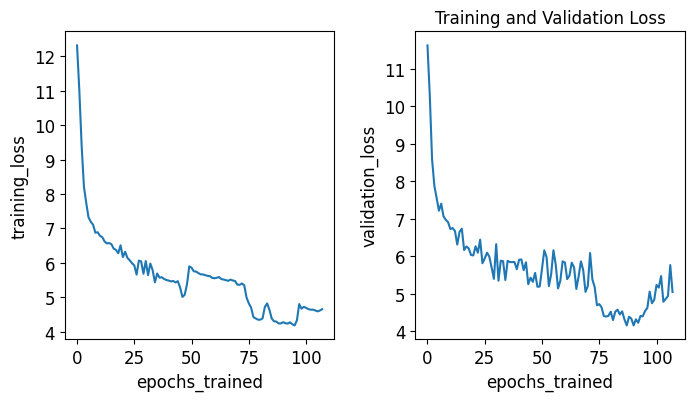

In [13]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

## Posterior distributions for different sequence length

In [15]:
theta_trained_2000 = posterior.set_default_x(x_o_2000).sample((num_posterior_samples,), x=x_o_2000)
theta_trained_2000_numpy = theta_trained_2000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 28781.73it/s]


In [16]:
theta_trained_500 = posterior.set_default_x(x_o_500).sample((num_posterior_samples,), x=x_o_500)
theta_trained_500_numpy = theta_trained_500.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 34004.65it/s]


In [17]:
theta_trained_6000 = posterior.set_default_x(x_o_6000).sample((num_posterior_samples,), x=x_o_6000)
theta_trained_6000_numpy = theta_trained_6000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 15776.72it/s]


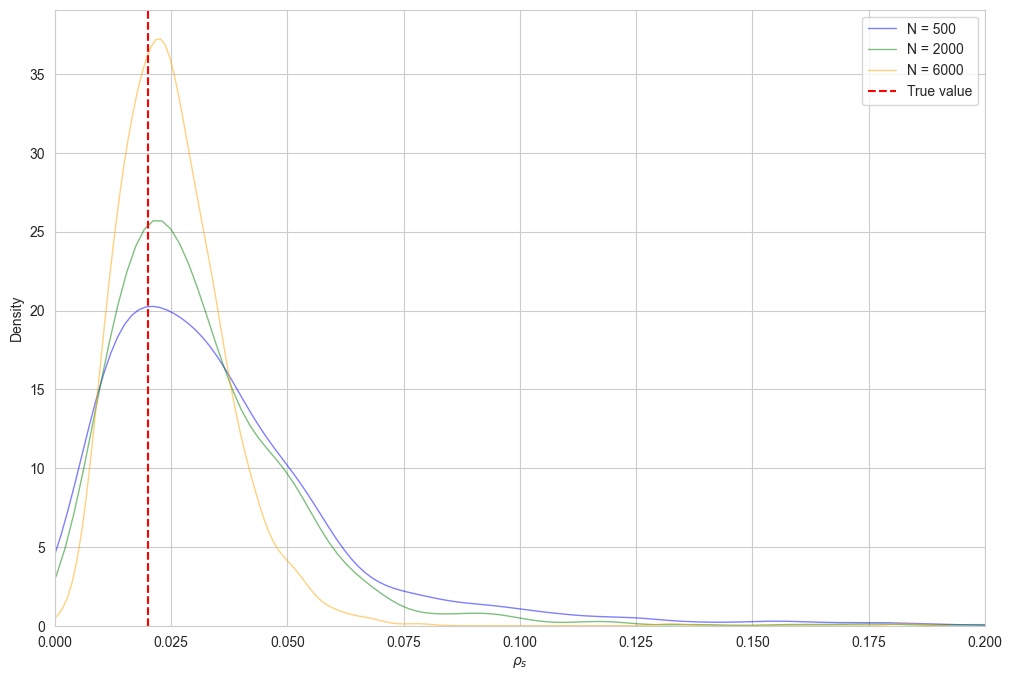

In [18]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 0], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 0], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 0], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

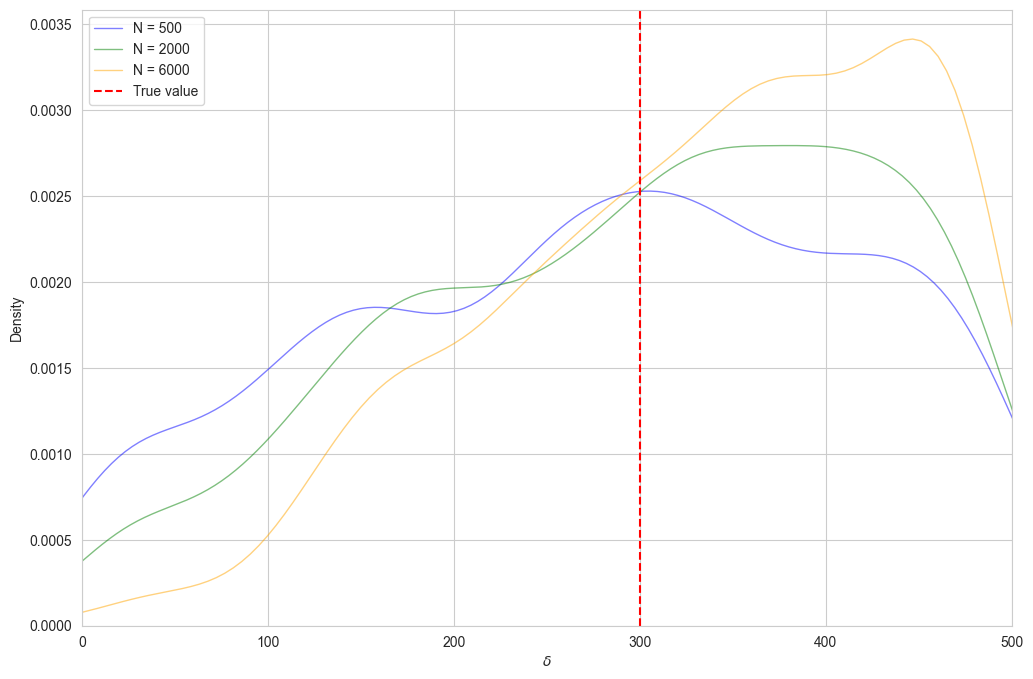

In [19]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 1], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 1], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 1], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=300, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\delta$')
plt.xlim(0.0, 500.0)
plt.legend()
plt.show()

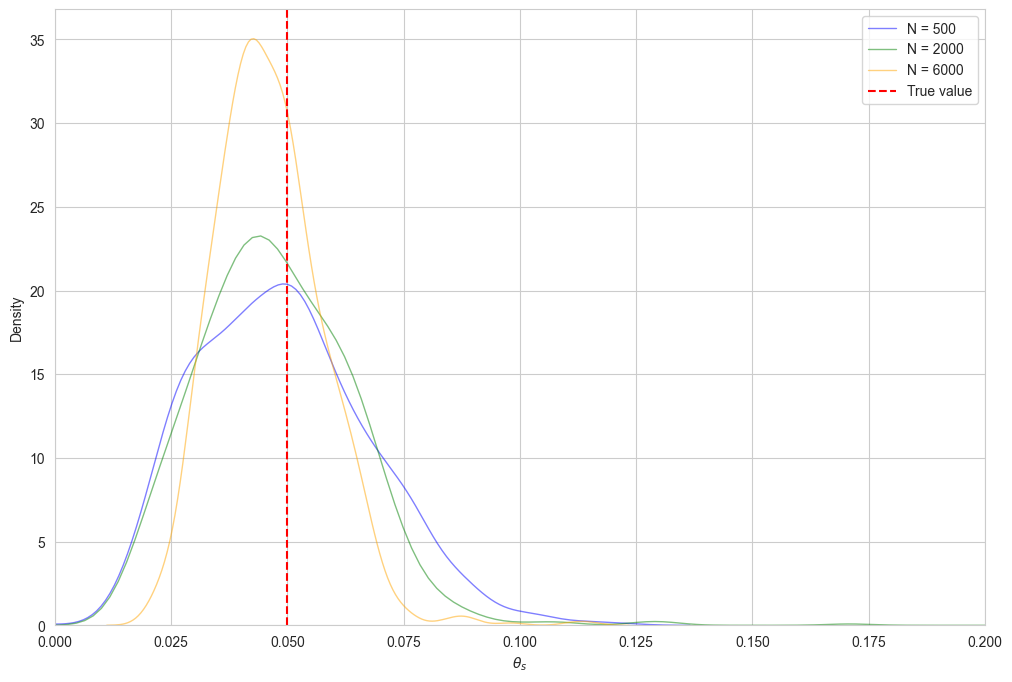

In [20]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 2], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 2], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 2], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.05, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\theta_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

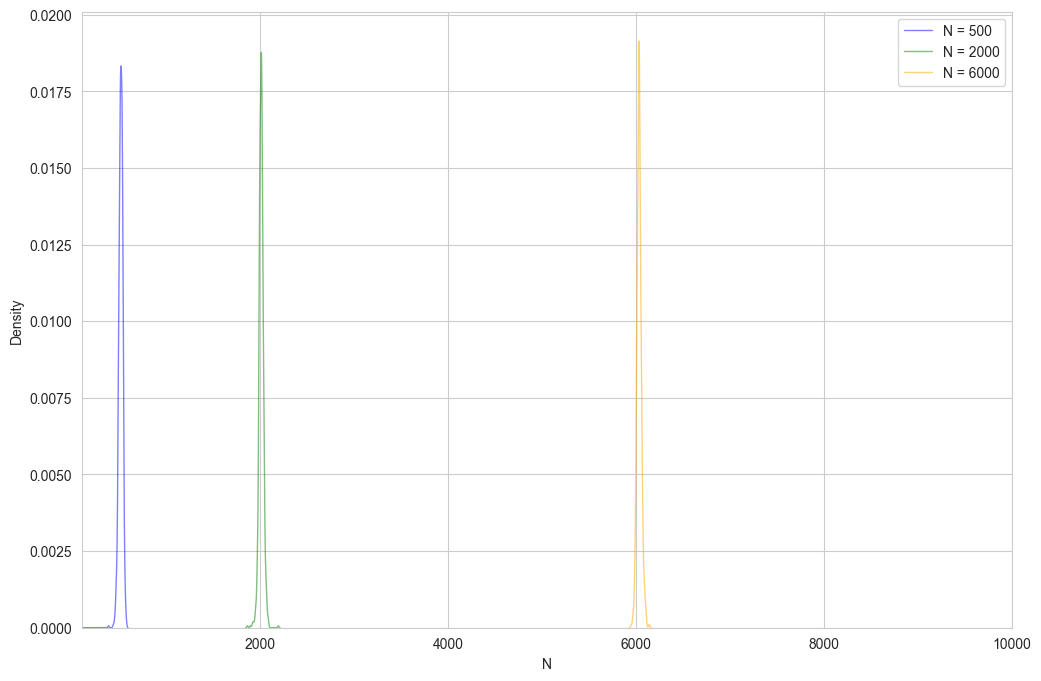

In [21]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 3], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 3], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 3], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

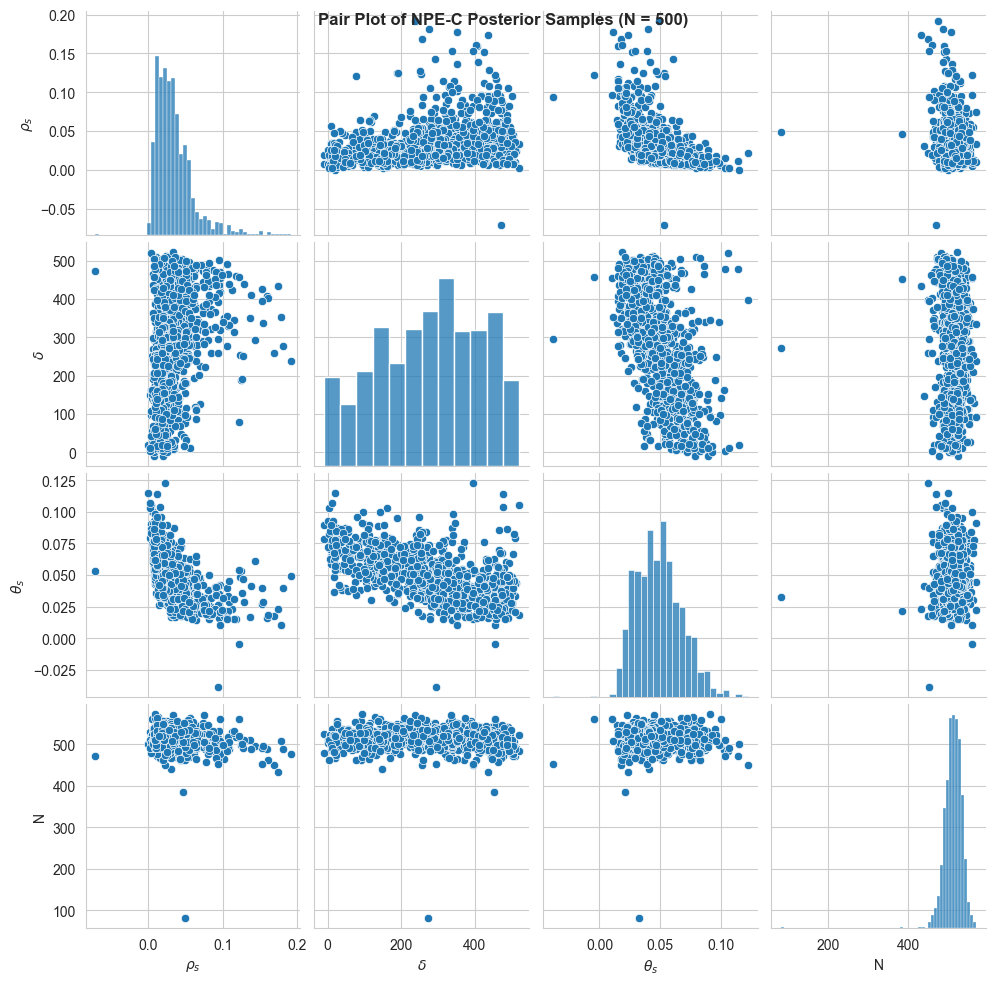

In [22]:
df_500 = pd.DataFrame(theta_trained_500_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

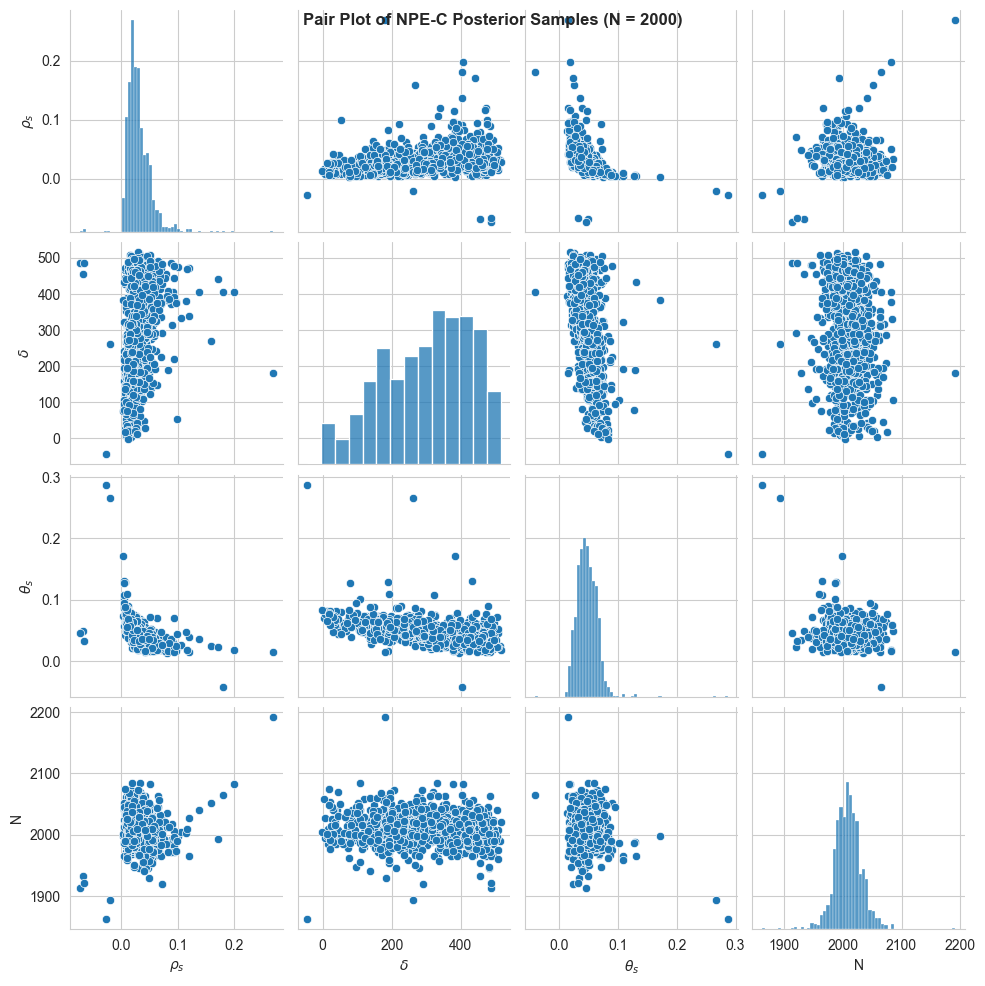

In [23]:
df_2000 = pd.DataFrame(theta_trained_2000_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

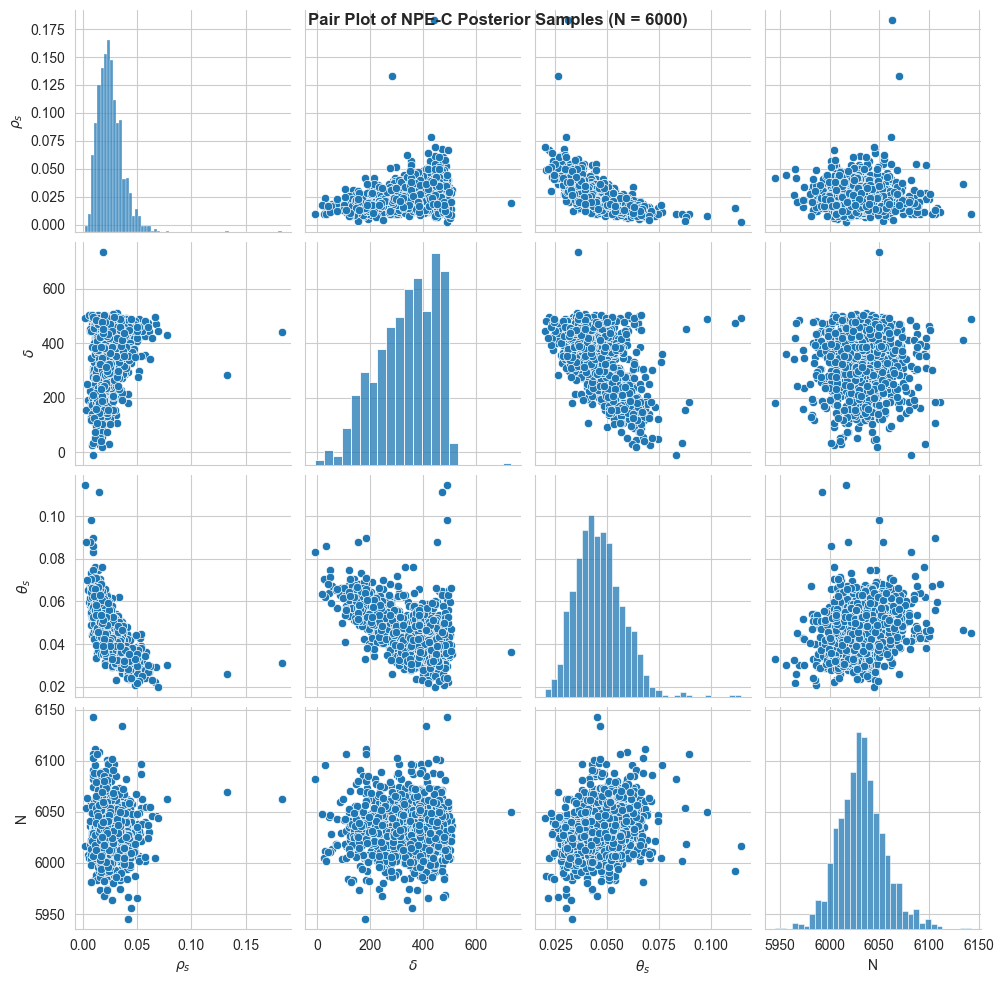

In [24]:
df_6000 = pd.DataFrame(theta_trained_6000_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

## Comment

1. NPE works for the sequential model in general. We see the posterior variances changes by the length.

2. It provide good posterior distribution to $\rho_s$, $\theta_s$ and $N$. But not a good estimation to $\delta$. Possible reason: true $\delta$ is larger than all three distances used for summary statistics.

3. Even the posterior for $\rho_s$, $\theta_s$ are less confident than the posterior from pair model. Pair model run $N$ different pairs at every distance. But the sequential model run one entire sequence of length $N$, the summary statistics are more correlated.

4. Still simulating truncated mutations? And $S$, the proportion of segregating sites, is zero or close to zero here.